# QPD VNA Simulator

End-to-end demo of `qpd.simulator`: generate a realistic I/Q timeseries of a QPD transmon coupled to a notch-type readout resonator (Probst et al., RSI 86, 024706 (2015), Eq. 1), with quasiparticle tunneling modeled as two independent Poisson processes (Γ_even→odd, Γ_odd→even).

Composable n_g(t) model: a slow sawtooth drift (cf. Fig. 7 top of arXiv:2405.17192) plus discrete charge-jump events.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qpd import (
    QPD,
    VNASimulator,
    ResonatorConfig,
    WhiteGaussianNoise,
    SawtoothNg,
    ChargeJumpEvents,
    ConstantNg,
)

plt.style.use(QPD._style_path)

## 1. Build the QPD device

Pick E_J, E_C in the QPD regime (E_J/E_C ≈ 12 here) and set the transmon–resonator coupling g.

In [2]:
qpd = QPD(e_j_hz=8.335e9, e_c_hz=0.695e9)
qpd.coupling_g_hz = 150e6
print(f'E_J/E_C = {qpd.e_j_hz / qpd.e_c_hz:.2f}')
print(f'g       = {qpd.coupling_g_hz / 1e6:.1f} MHz')

E_J/E_C = 11.99
g       = 150.0 MHz


## 2. Resonator + measurement environment

`ResonatorConfig` carries the bare resonance (`f_r`), the quality factors (`q_i`, `q_c_abs`), the impedance-mismatch angle `φ`, and the VNA environment parameters `a, α, τ` that the simulator applies to produce uncalibrated I/Q in raw electronic coordinates.

In [3]:
resonator = ResonatorConfig(
    f_r=6.937e9,
    q_i=1.5e5,
    q_c_abs=1e5,
    phi=0.03,
    a=0.5,
    alpha=0.4,
    tau=50e-9,
)
print(f'Q_l = {resonator.q_l():.0f}')

Q_l = 60016


## 3. Offset-charge model

Components compose via `+`. Here: a slow sawtooth ramping at 0.05 /s between ±0.5, plus three discrete charge-jump events.

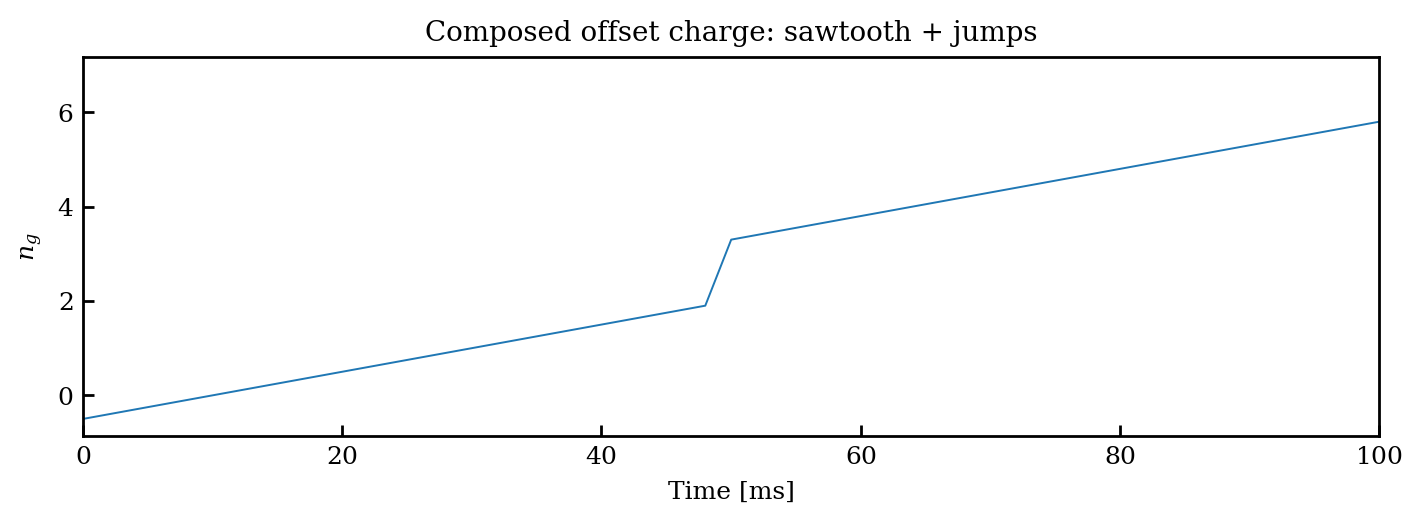

In [4]:
n_g_model = SawtoothNg(
    n_g_min=-0.5, n_g_max=5, slope=50,
) + ChargeJumpEvents(
    times=np.array([0.05, 1.2, 3.5, 7.8]),
    deltas=np.array([+1.3, +0.3, -0.2, +0.4]),
)

# Preview n_g(t)
t_preview = np.linspace(0, 10, 5000)
fig, ax = plt.subplots(figsize=(7, 2.5))
ax.plot(t_preview*1000, n_g_model.evaluate(t_preview), lw=0.7)
ax.set_xlabel('Time [ms]')
ax.set_ylabel(r'$n_g$')
ax.set_title('Composed offset charge: sawtooth + jumps')
plt.xlim(0, 100)
plt.show()

## 4. Run the simulation

Two Poisson rates set the parity-flip dynamics; their ratio determines the steady-state populations.

In [5]:
gamma_e_to_o = 200.0
gamma_o_to_e = 500.0
p_odd_expected = gamma_e_to_o / (gamma_e_to_o + gamma_o_to_e)

sim = VNASimulator(
    qpd=qpd,
    resonator=resonator,
    f_drive=6.937e9,
    sample_rate=1e5,
    gamma_even_to_odd=gamma_e_to_o,
    gamma_odd_to_even=gamma_o_to_e,
    noise=WhiteGaussianNoise(sigma=2e-5),
    offset_charge=n_g_model,
)

result = sim.simulate(duration=10.0, seed=0)

frac_odd = float(np.mean(result.parity == 1))
print(f'Empirical P(odd) = {frac_odd:.4f}')
print(f'Predicted P(odd) = {p_odd_expected:.4f}')
print(f'Samples          = {result.t.size:,}')

Empirical P(odd) = 0.2946
Predicted P(odd) = 0.2857
Samples          = 1,000,000


## 5. Inspect I(t), Q(t)

Zoom into the first 50 ms so individual parity flips are visible.

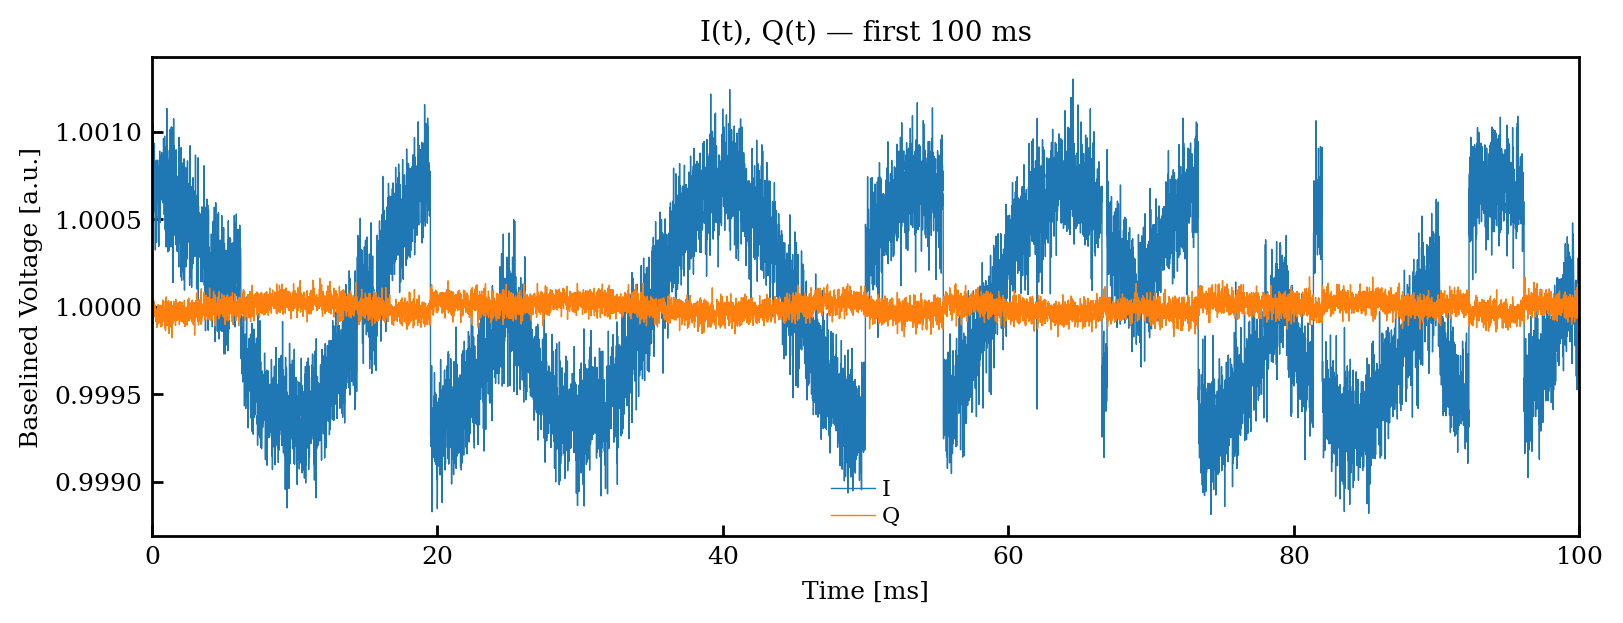

In [7]:
zoom = result.t < 0.1
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(result.t[zoom] * 1e3, result.i[zoom] / np.mean(result.i[zoom]), label='I', lw=0.5)
ax.plot(result.t[zoom] * 1e3, result.q[zoom] / np.mean(result.q[zoom]), label='Q', lw=0.5)
ax.set_xlabel('Time [ms]')
ax.set_ylabel('Baselined Voltage [a.u.]')
ax.set_title('I(t), Q(t) — first 100 ms')
ax.legend()
plt.xlim(0, 100)
plt.show()

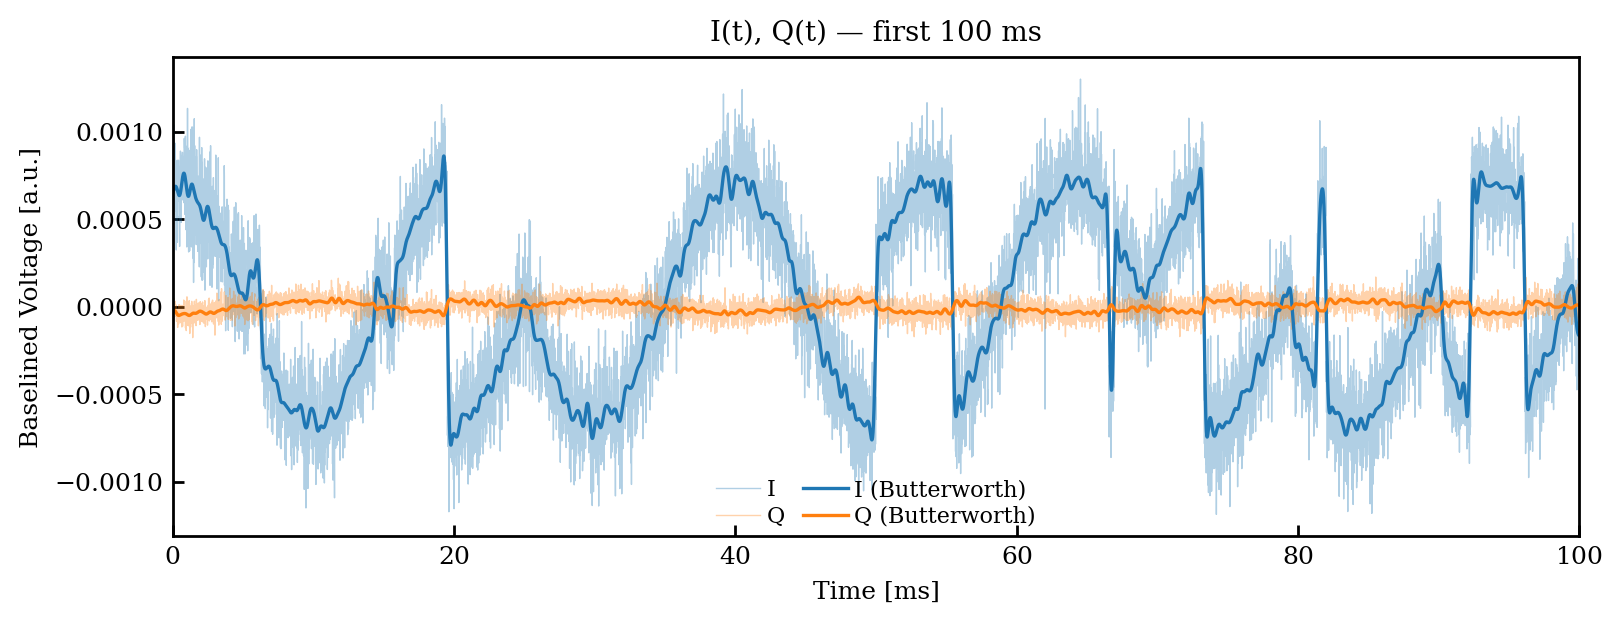

In [18]:
from scipy.signal import butter, filtfilt

zoom = result.t < 0.1
t_ms = result.t[zoom] * 1e3
i_norm = result.i[zoom] / np.mean(result.i[zoom]) - 1
q_norm = result.q[zoom] / np.mean(result.q[zoom]) - 1

dt = float(np.mean(np.diff(result.t)))
fs_hz = 1.0 / dt
cutoff_hz = 2_000.0
b, a = butter(N=4, Wn=cutoff_hz, btype='low', fs=fs_hz)
i_filt = filtfilt(b, a, i_norm)
q_filt = filtfilt(b, a, q_norm)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_ms, i_norm, label='I ', lw=0.5, alpha=0.35)
ax.plot(t_ms, q_norm, label='Q', lw=0.5, alpha=0.35)
ax.plot(t_ms, i_filt, label='I (Butterworth)', lw=1.2, color="tab:blue")
ax.plot(t_ms, q_filt, label='Q (Butterworth)', lw=1.2, color="tab:orange")
ax.set_xlabel('Time [ms]')
ax.set_ylabel('Baselined Voltage [a.u.]')
ax.set_title('I(t), Q(t) — first 100 ms')
ax.legend(ncol=2)
plt.xlim(0, 100)
plt.show()

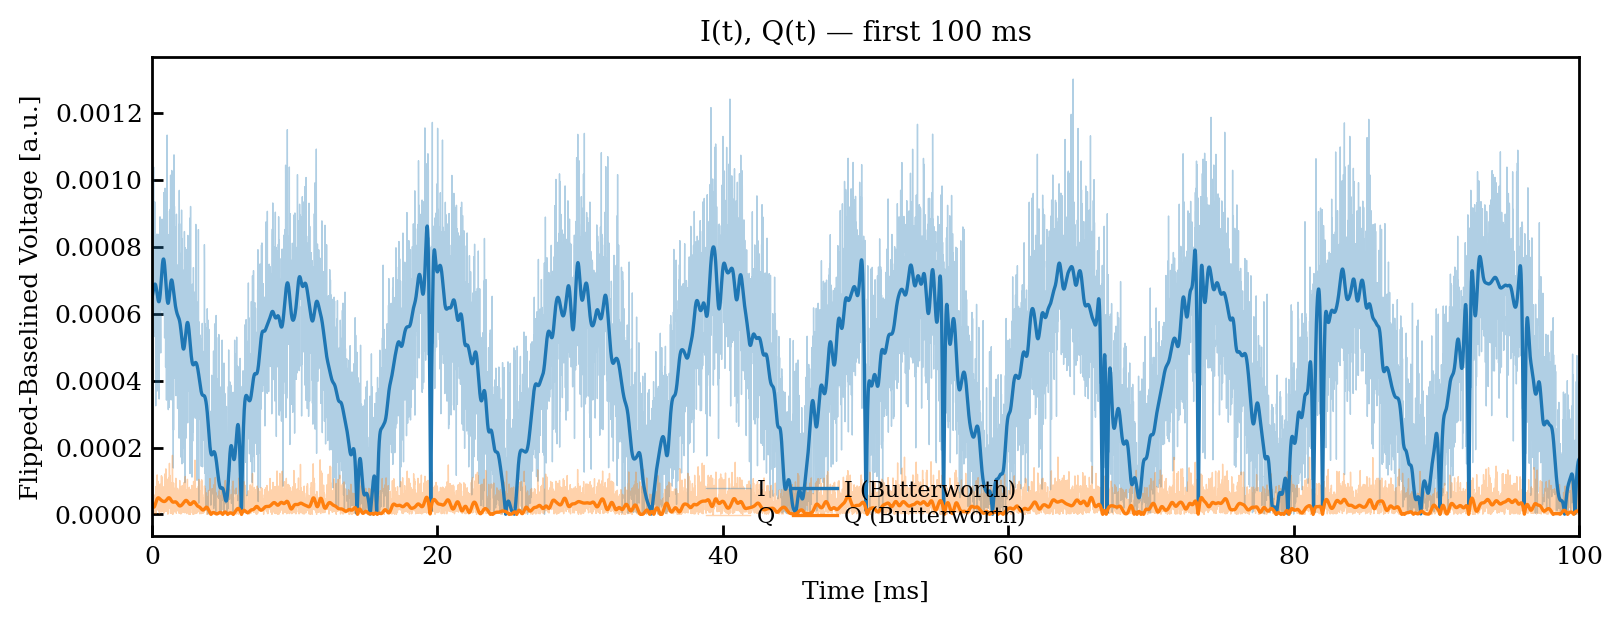

In [19]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_ms, np.abs(i_norm), label='I ', lw=0.5, alpha=0.35)
ax.plot(t_ms, np.abs(q_norm), label='Q', lw=0.5, alpha=0.35)
ax.plot(t_ms, np.abs(i_filt), label='I (Butterworth)', lw=1.2, color="tab:blue")
ax.plot(t_ms, np.abs(q_filt), label='Q (Butterworth)', lw=1.2, color="tab:orange")
ax.set_xlabel('Time [ms]')
ax.set_ylabel('Flipped-Baselined Voltage [a.u.]')
ax.set_title('I(t), Q(t) — first 100 ms')
ax.legend(ncol=2)
plt.xlim(0, 100)
plt.show()

(0.0, 100.0)

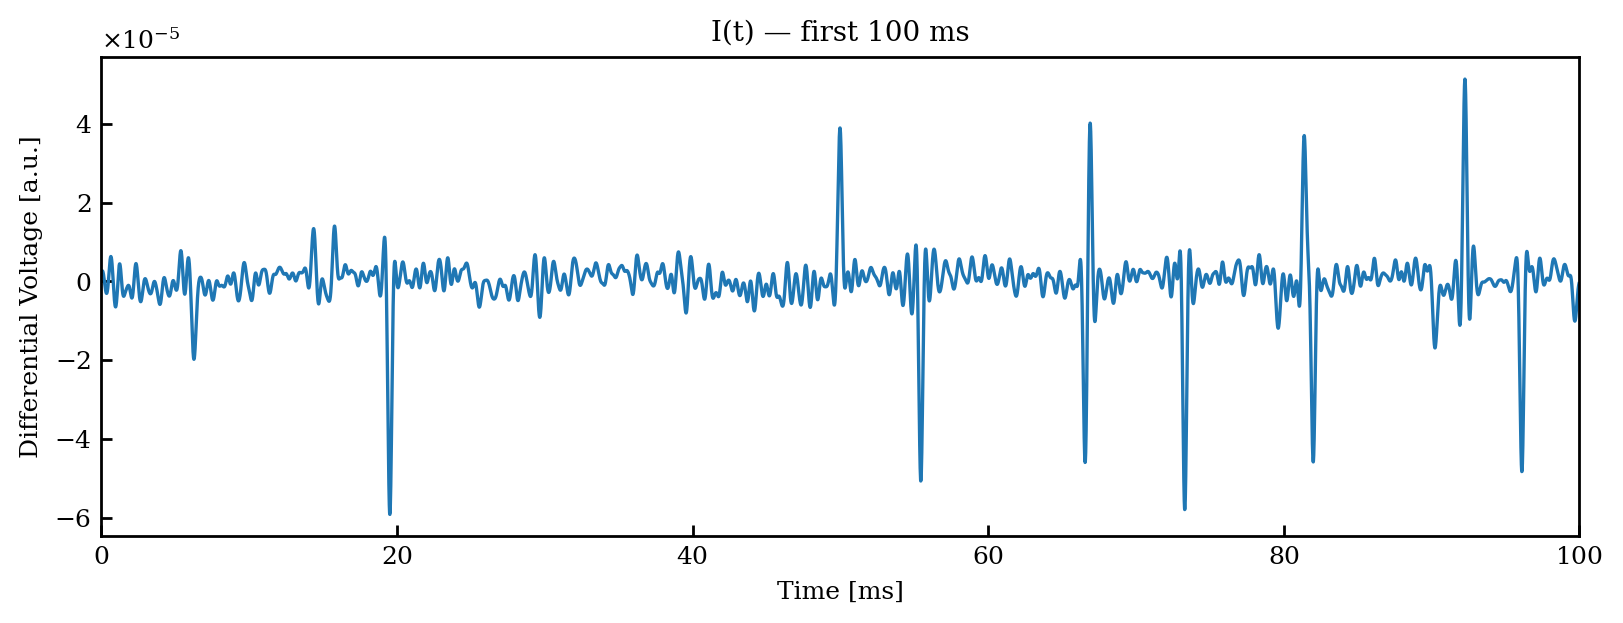

In [13]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_ms[:-1], np.diff(i_filt), label='I (Butterworth)', lw=1.2)
ax.set_xlabel('Time [ms]')
ax.set_ylabel('Differential Voltage [a.u.]')
ax.set_title('I(t) — first 100 ms')
plt.xlim(0, 100)

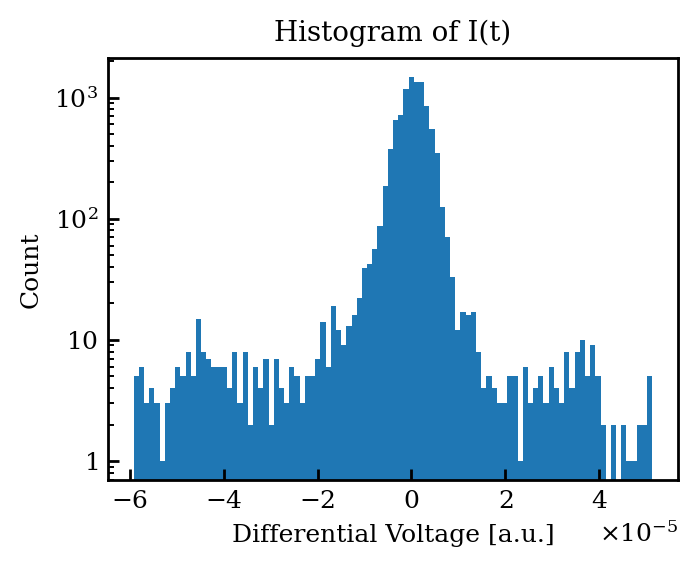

In [15]:
plt.hist(np.diff(i_filt), bins=100)
plt.xlabel('Differential Voltage [a.u.]')
plt.ylabel('Count')
plt.title('Histogram of I(t)')
plt.yscale('log')
plt.show()

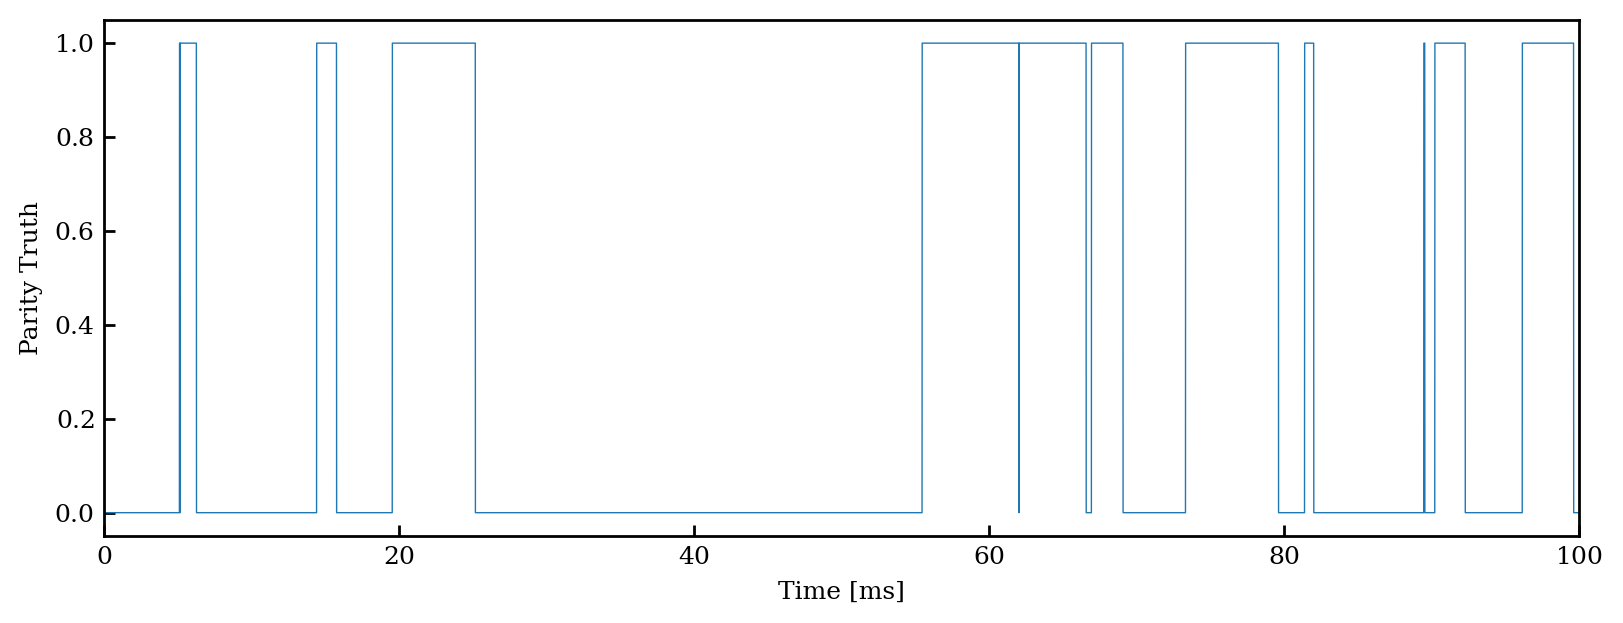

In [8]:
zoom = result.t < 0.1
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(result.t[zoom] * 1e3, result.parity[zoom], label='parity', lw=0.5)
ax.set_xlabel('Time [ms]')
ax.set_ylabel('Parity Truth')
#ax.set_title('parity')
#ax.legend()
plt.xlim(0, 100)
plt.show()

## 6. IQ scatter — parity clusters

Color samples by their parity. With SNR > 1 the two clusters separate cleanly.

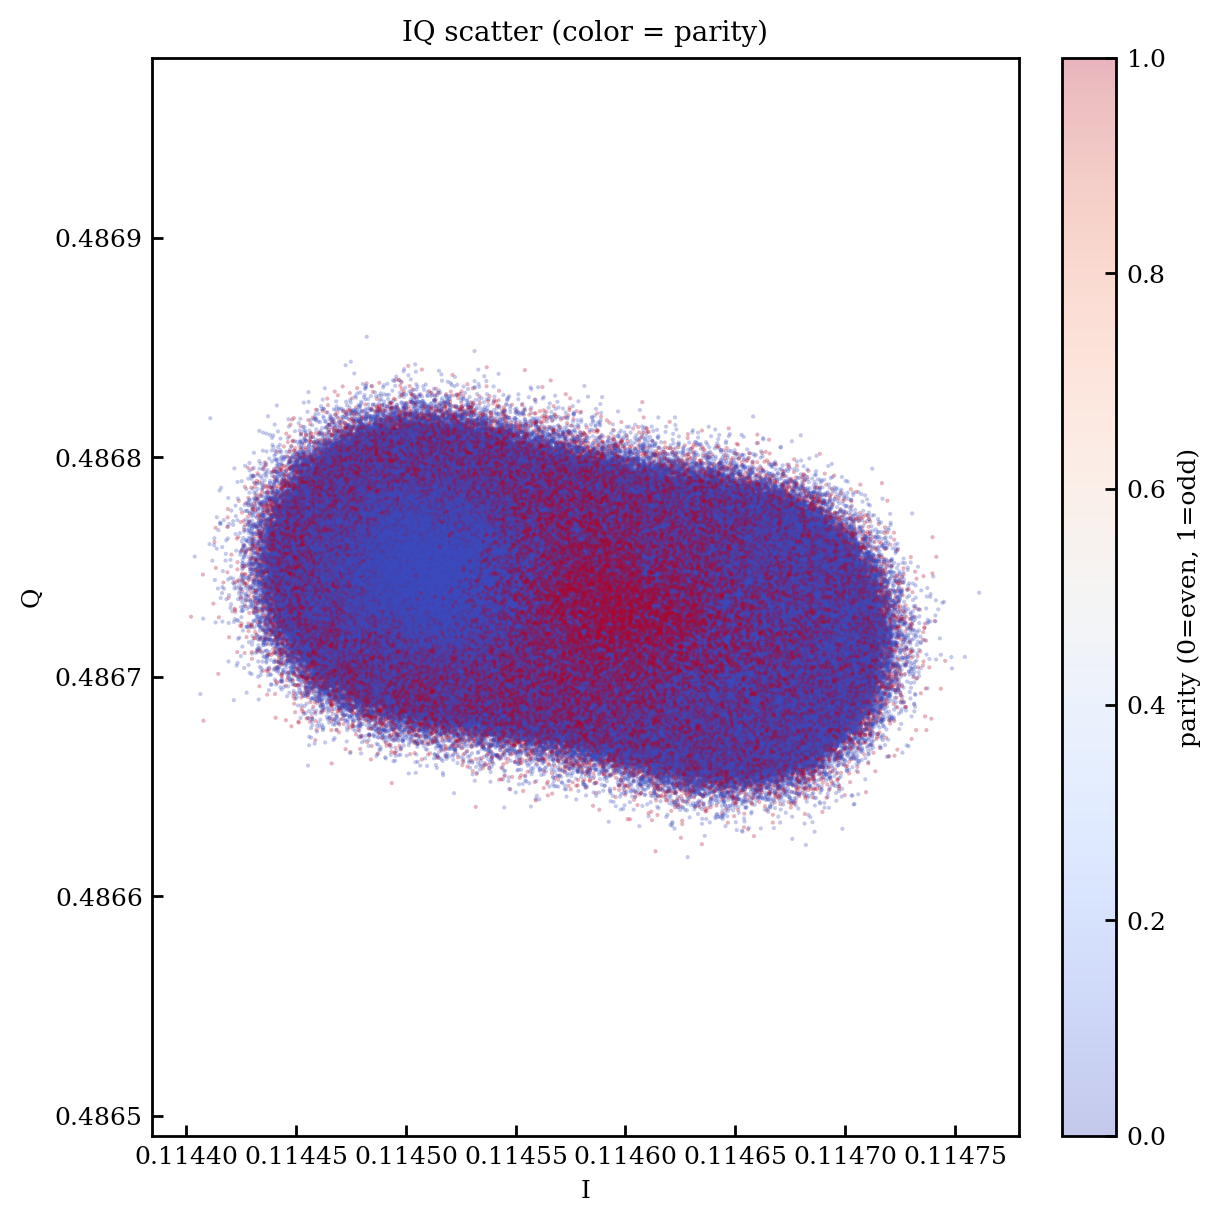

In [32]:
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(
    result.i, result.q,
    c=result.parity, cmap='coolwarm', s=1, alpha=0.3,
)
ax.set_xlabel('I')
ax.set_ylabel('Q')
ax.set_aspect('equal', adjustable='datalim')
ax.set_title('IQ scatter (color = parity)')
plt.colorbar(sc, ax=ax, label='parity (0=even, 1=odd)')
plt.show()

## 7. n_g(t) trajectory used by the simulator

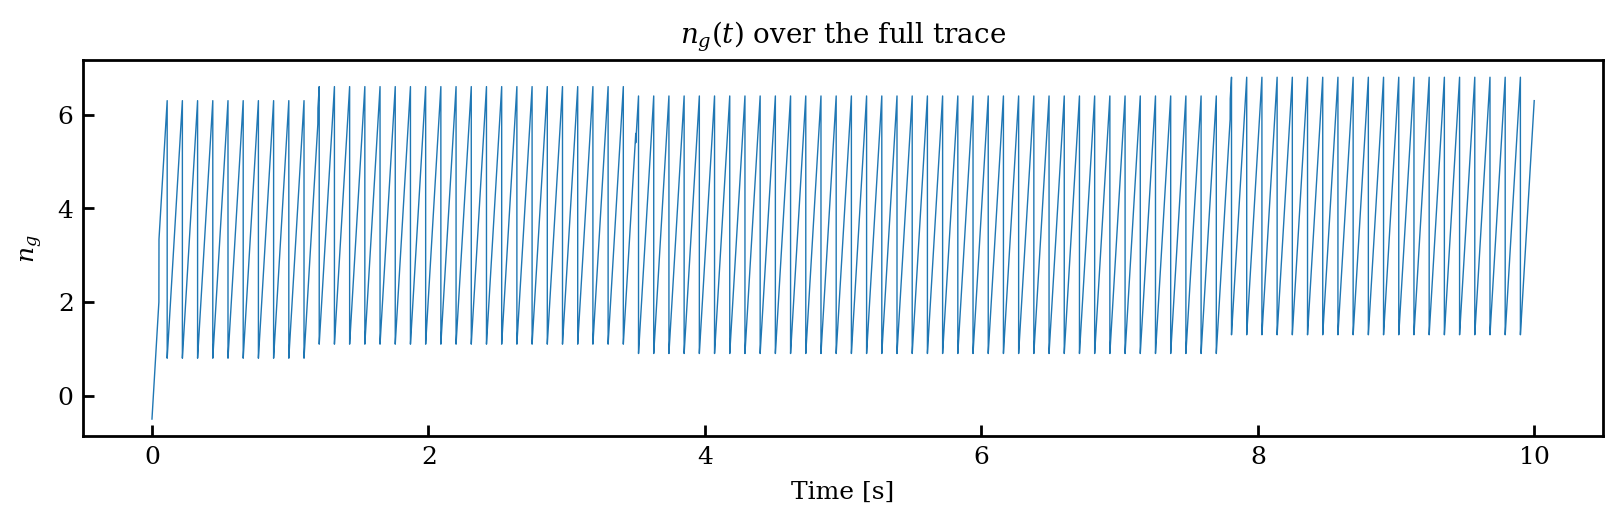

In [33]:
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(result.t, result.n_g, lw=0.5)
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'$n_g$')
ax.set_title(r'$n_g(t)$ over the full trace')
plt.show()

## 8. Try other n_g configurations

The composable interface makes it trivial to swap in alternatives without touching the simulator.

/var/folders/b4/tkxxqysd1pd6vc7155459qcm0000gn/T/ipykernel_65574/2167360544.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


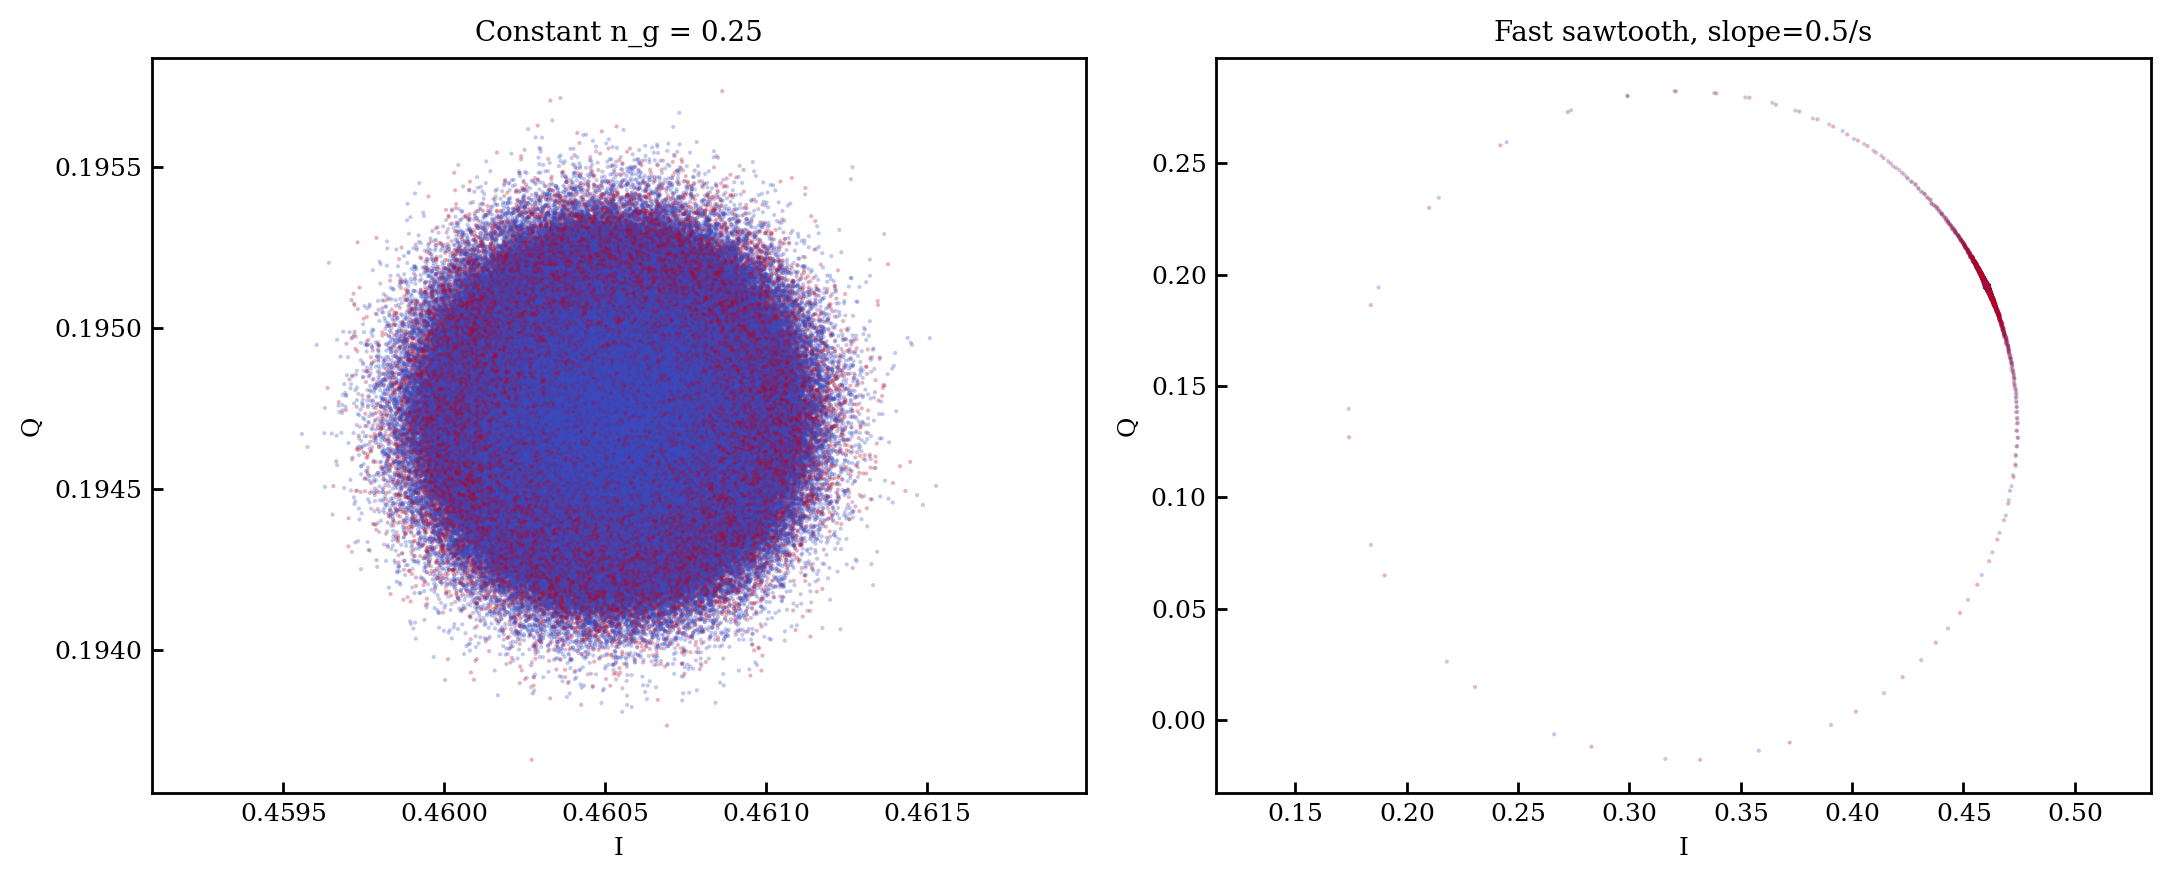

In [34]:
# (a) Fixed n_g at 0.25
sim_a = VNASimulator(
    qpd=qpd, resonator=resonator,
    f_drive=6.0e9, sample_rate=1e6,
    gamma_even_to_odd=gamma_e_to_o, gamma_odd_to_even=gamma_o_to_e,
    noise=WhiteGaussianNoise(sigma=2e-4),
    offset_charge=ConstantNg(0.25),
)
res_a = sim_a.simulate(duration=2.0, seed=1)

# (b) Sawtooth only, no discrete jumps
sim_b = VNASimulator(
    qpd=qpd, resonator=resonator,
    f_drive=6.0e9, sample_rate=1e6,
    gamma_even_to_odd=gamma_e_to_o, gamma_odd_to_even=gamma_o_to_e,
    noise=WhiteGaussianNoise(sigma=2e-4),
    offset_charge=SawtoothNg(-0.5, 0.5, slope=0.5),
)
res_b = sim_b.simulate(duration=2.0, seed=2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, res, title in zip(axes, [res_a, res_b], ['Constant n_g = 0.25', 'Fast sawtooth, slope=0.5/s']):
    ax.scatter(res.i, res.q, c=res.parity, cmap='coolwarm', s=1, alpha=0.3)
    ax.set_xlabel('I')
    ax.set_ylabel('Q')
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_title(title)
plt.tight_layout()
plt.show()